In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os, sys
from pathlib import Path
import functools

from extra.components import XrayPulses
import extra_data as ex
from extra_data.components import AGIPD1M
from extra_geom import AGIPD_1MGeometry
from extra_data import by_index
import extra_speckle as esp
from extra_speckle.setup import Setup

from dask_jobqueue import SLURMCluster
from dask.distributed import Client
import dask.array as da

import numpy as np
import matplotlib.pyplot as plt
import h5py
from pyFAI.integrator.azimuthal import AzimuthalIntegrator

import damnit

In [2]:
db = damnit.Damnit(10400)

In [3]:
run_nr = 488
bg_run_nr = 464

In [4]:
def plot_saxs_series(dataset, ax, step=100, bg=None):
    q = dataset.q.values
    pulse = dataset.pulseId.values
    for i in range(0, len(dataset.trainId)-step, step):
        iq = dataset.isel(trainId=slice(i, i+step)).mean(["trainId", "pulseId"]).data
        if bg is not None:
            iq -= bg
        ax.loglog(q, iq)
    return ax

In [5]:
saxs_data = db[run_nr]["agipd_saxs"].read()

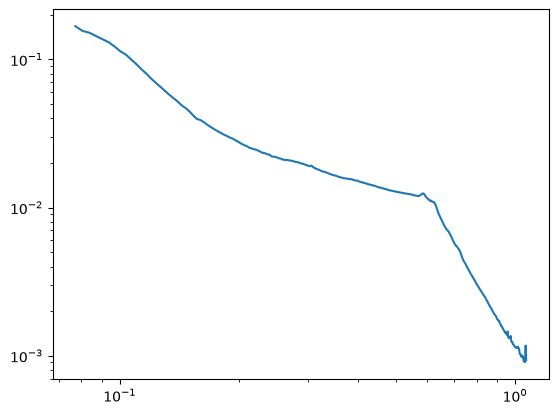

In [7]:
avg = saxs_data.mean(["trainId", "pulseId"])
q, iq = avg.q.values, avg.data
plt.loglog(q, iq)
plt.show()

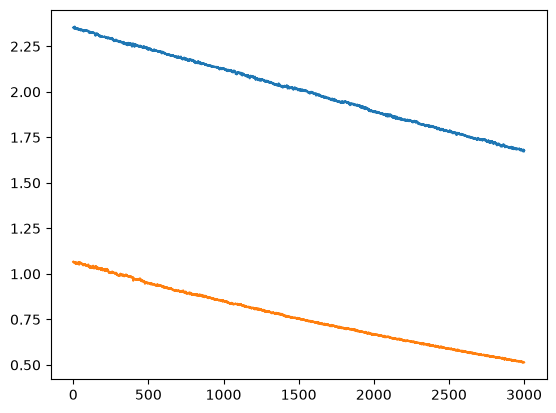

In [37]:
plt.plot(db[run_nr]["droplet_fit"].read().volume.data, label=f"Sample r{run_nr}")
plt.plot(db[bg_run_nr]["droplet_fit"].read().volume.data, label=f"Bg r{bg_run_nr}")

In [38]:
np.save("droplet_radius_r423", db[run_nr]["droplet_fit"].read().volume.data)
np.save("droplet_radius_r464", db[bg_run_nr]["droplet_fit"].read().volume.data)

In [29]:
db[run_nr].keys()

['agipd_iq_overview',
 'agipd_saxs',
 'droplet_fit',
 'n_trains',
 'opt_transmission',
 'proc_size',
 'pulses',
 'raw_size',
 'rep_rate',
 'run_length',
 'run_type',
 'sample',
 'start_time',
 'total_transmission',
 'xgm_intensity',
 'xgm_overview_plot',
 'xpcs_correction_plot',
 'xpcs_g2_fit_plot',
 'xpcs_g2_plot',
 'xpcs_kbar_plot',
 'xpcs_mean_dataset',
 'xpcs_outliers_plot',
 'xpcs_pipeline',
 'xpcs_q_rings_plot',
 'xpcs_saxs',
 'xpcs_saxs_plot',
 'xpcs_sdd',
 'xpcs_ttcf',
 'xpcs_ttcfs_plot',
 'xtd1_transmission',
 'xtd6_transmission']